# Lab 9.2: CNN Training with Image Augmentation

**Name:** Zubair Moeen  
**Reg Number:** 22jzele0463  
**Lab:** Machine Learning Lab  
**Lab Supervisor:** Engr.Irshad Ullah  
**University:** UET Peshawar - Campus Nowshera 

## Lab Overview
This notebook trains a custom CNN for corn leaf image classification using image data generators. The code defines the model architecture, compiles it, applies augmentation/rescaling, trains the model with checkpoints, and evaluates classification performance.

## Learning Objectives
- Import required TensorFlow/Keras and evaluation libraries.
- Define image dataset paths for training, validation, and testing.
- Build and compile a CNN model for image classification.
- Use ImageDataGenerator for rescaling and augmentation.
- Train the model and evaluate it using plots, confusion matrix, and classification report.

## Section 1: Library Import and Dataset Paths
This section imports Keras tools, plotting libraries, and evaluation metrics, then defines paths for train, validation, and test image folders.


In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [2]:
checkpoints = r'Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [3]:
train_dir = r'Z:\University\8th Semester\ML Lab\Lab 9\Computer vision\sectionB\train'
validation_dir = r'Z:\University\8th Semester\ML Lab\Lab 9\Computer vision\sectionB\validation'
test_dir = r'Z:\University\8th Semester\ML Lab\Lab 9\Computer vision\sectionB\test'

## Section 2: CNN Model Architecture
The following cells create and summarize the convolutional neural network used for classification.


In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4, activation='sigmoid'))

c:\Users\engin\.conda\envs\ml\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [7]:
train_datagen = ImageDataGenerator(
                                    rescale=1./255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
                                                    train_dir,
                                                    target_size=(256, 256),
                                                    batch_size=32,
                                                    class_mode='categorical')

validation_generator = test_datagen.flow_from_directory(
                                                        validation_dir,
                                                        target_size=(256, 256),
                                                        batch_size=32,
                                                        class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## Section 3: Data Generators, Augmentation, and Training
This section prepares image generators, applies rescaling/augmentation, sets checkpoints, and trains the CNN model.


In [8]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [9]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [10]:
model_history = model.fit(train_generator,
                         validation_data =validation_generator,
                         steps_per_epoch=train_generator.n//train_generator.batch_size,
                         validation_steps = validation_generator.n//validation_generator.batch_size,
                         epochs = 10,
                         callbacks = callbacks)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3849 - loss: 1.2544
Epoch 1: val_loss improved from None to 0.63361, saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0001-loss0.63.h5



Epoch 1: finished saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0001-loss0.63.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.5063 - loss: 1.0860 - val_accuracy: 0.7812 - val_loss: 0.6336
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7218 - loss: 0.6508
Epoch 2: val_loss improved from 0.63361 to 0.42268, saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0002-loss0.42.h5



Epoch 2: finished saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0002-loss0.42.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7394 - loss: 0.5913 - val_accuracy: 0.7902 - val_loss: 0.4227
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8117 - loss: 0.4240
Epoch 3: val_loss did not improve from 0.42268
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8056 - loss: 0.4365 - val_accuracy: 0.7098 - val_loss: 0.7388
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8134 - loss: 0.4012
Epoch 4: val_loss improved from 0.42268 to 0.41683, saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0004-loss0.42.h5



Epoch 4: finished saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0004-loss0.42.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8188 - loss: 0.4023 - val_accuracy: 0.8036 - val_loss: 0.4168
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8335 - loss: 0.3284
Epoch 5: val_loss improved from 0.41683 to 0.29420, saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0005-loss0.29.h5



Epoch 5: finished saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0005-loss0.29.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8438 - loss: 0.3360 - val_accuracy: 0.8616 - val_loss: 0.2942
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8412 - loss: 0.3502
Epoch 6: val_loss did not improve from 0.29420
50/50 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8556 - loss: 0.3213 - val_accuracy: 0.8170 - val_loss: 0.3188
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8634 - loss: 0.2864
Epoch 7: val_loss improved from 0.29420 to 0.28843, saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0007-loss0.29.h5



Epoch 7: finished saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0007-loss0.29.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8637 - loss: 0.2899 - val_accuracy: 0.8795 - val_loss: 0.2884
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8750 - loss: 0.2758
Epoch 8: val_loss improved from 0.28843 to 0.27813, saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0008-loss0.28.h5



Epoch 8: finished saving model to Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0008-loss0.28.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8825 - loss: 0.2699 - val_accuracy: 0.8839 - val_loss: 0.2781
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9005 - loss: 0.2270
Epoch 9: val_loss did not improve from 0.27813
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8963 - loss: 0.2394 - val_accuracy: 0.8170 - val_loss: 0.3482
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9031 - loss: 0.2279
Epoch 10: val_loss did not improve from 0.27813
50/50 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9100 - loss: 0.2244 - val_accuracy: 0.8705 - val_loss: 0.3106


In [11]:
model_history.history

{'accuracy': [0.5062500238418579,
  0.7393749952316284,
  0.8056250214576721,
  0.8187500238418579,
  0.84375,
  0.8556249737739563,
  0.8637499809265137,
  0.8824999928474426,
  0.8962500095367432,
  0.9100000262260437],
 'loss': [1.0860052108764648,
  0.5912570357322693,
  0.43645739555358887,
  0.4022822678089142,
  0.33603888750076294,
  0.32131075859069824,
  0.28991156816482544,
  0.2698558568954468,
  0.23938797414302826,
  0.2243528962135315],
 'val_accuracy': [0.78125,
  0.7901785969734192,
  0.7098214030265808,
  0.8035714030265808,
  0.8616071343421936,
  0.8169642686843872,
  0.8794642686843872,
  0.8839285969734192,
  0.8169642686843872,
  0.8705357313156128],
 'val_loss': [0.6336095929145813,
  0.4226832389831543,
  0.7387733459472656,
  0.41683337092399597,
  0.2942048907279968,
  0.3187697231769562,
  0.28843361139297485,
  0.27812737226486206,
  0.3482186794281006,
  0.31064659357070923]}

## Section 4: Model Evaluation
The final cells evaluate model performance using plots, predictions, confusion matrix, and classification report.


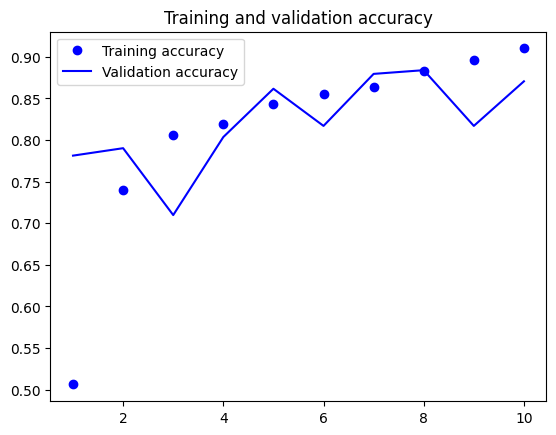

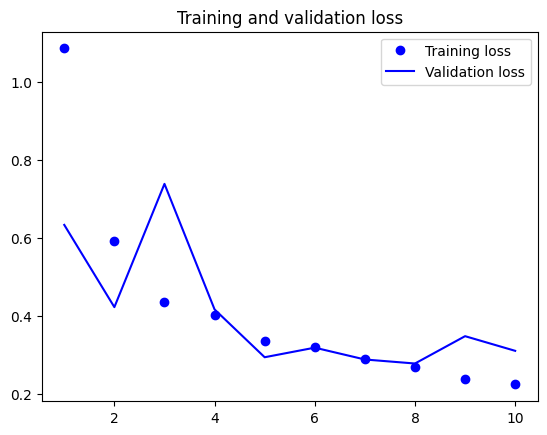

In [12]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 9\model_Accuracy.png')

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 9\model_Loss.png')

plt.show()

Found 200 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 506ms/step


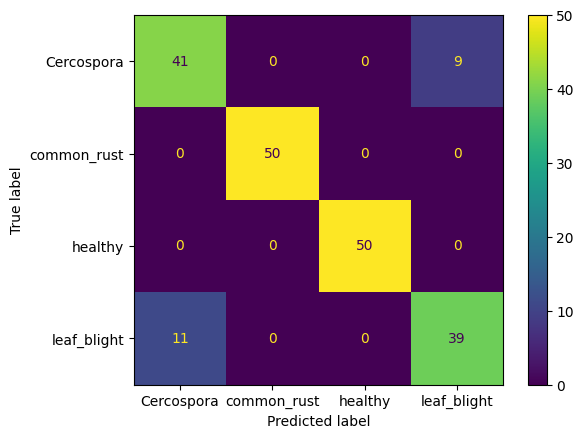

In [13]:
model = load_model(r'Z:\University\8th Semester\ML Lab\Lab 9\\E1-cp-0008-loss0.28.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

In [14]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.79      0.82      0.80        50
 common_rust       1.00      1.00      1.00        50
     healthy       1.00      1.00      1.00        50
 leaf_blight       0.81      0.78      0.80        50

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



## Final Conclusion
In this lab, a CNN model was trained using image augmentation and evaluated on corn leaf image classes. This workflow connects dataset preparation, augmentation, model training, and classification evaluation.

